In [ ]:
#Data Preprocessing
import pandas as pd
import numpy as np

DGS1 = pd.read_csv('data/DGS1.csv')  
DGS2 = pd.read_csv('data/DGS2.csv')
DGS5 = pd.read_csv('data/DGS5.csv')
DGS10 = pd.read_csv('data/DGS10.csv')    

print(DGS2.shape, DGS5.shape, DGS10.shape) #Print the shapes of the dataframes to verify successful loading
print(DGS2.info(),DGS5.info(), DGS10.info()) #Print the info of the dataframe to check data types and non-null counts

merged = DGS2.merge(DGS5, on="observation_date", how="inner").merge(DGS10, on="observation_date", how="inner") #Merge the dataframes on observation_date
merged = merged.dropna(subset=["DGS2","DGS5","DGS10"]) #Drop rows with missing values in any of the yield columns

merged = merged.set_index("observation_date") #Set observation_date as index
merged.index = pd.to_datetime(merged.index, errors="coerce") #Convert index to datetime

DGS1 = DGS1.dropna(subset=["DGS1"]) #Drop rows with missing values in any of the yield columns

DGS1 = DGS1.set_index("observation_date") #Set observation_date as index
DGS1.index = pd.to_datetime(DGS1.index, errors="coerce") #Convert index to datetime



(4394, 2) (4394, 2) (4394, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4394 entries, 0 to 4393
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4394 non-null   object 
 1   DGS2              4214 non-null   float64
dtypes: float64(1), object(1)
memory usage: 68.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4394 entries, 0 to 4393
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4394 non-null   object 
 1   DGS5              4214 non-null   float64
dtypes: float64(1), object(1)
memory usage: 68.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4394 entries, 0 to 4393
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   observation_date  4394 non-null   object 
 1   DGS10             4214 n

# Preprocessing summary

-Loaded raw FRED CSVs (DGS2.csv, DGS5.csv, DGS10.csv) and inspected shapes/dtypes. We saw 4394 entries of which 4214 were non-null

-Merged the three series on the common key observation_date using an inner join.

-Dropped rows with missing yields in any of DGS2, DGS5, DGS10 (missing days are typically U.S. market holidays or occasional gaps) leaving us with the 4214 entries from before

-Converted observation_date to proper datetime and set it as the index to enable clean time-series operations

# Vizualizing the Dataset

In [2]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# Your data: merged (daily data), columns: ['DGS2', 'DGS5', 'DGS10']
data = merged.dropna()

# Extract maturities
maturities = np.array([2, 5, 10])

# Convert dates to numeric years
years = data.index.year + (data.index.dayofyear - 1) / 365

# Build surface arrays
X_mesh, Y_mesh = np.meshgrid(years, maturities)
Z = data.T.values   # shape (3 maturities, N dates)

# Create plot
fig = go.Figure(data=[
    go.Surface(
        x=X_mesh,
        y=Y_mesh,
        z=Z,
        colorscale='Viridis',
        colorbar=dict(title='Yield (%)')
    )
])

fig.update_layout(
    title='U.S. Treasury Yield Curves (2009–2025)',
    scene=dict(
        xaxis_title='Year',
        yaxis_title='Maturity (years)',
        zaxis_title='Yield (%)'
    ),
    width=900,
    height=600
)

fig.show()


# Descriptive Statistics

In [3]:
import pandas as pd
import numpy as np

# Select the three maturities (no resampling, just drop NaNs)
yields = merged[["DGS2", "DGS5", "DGS10"]].dropna()

# Build descriptive stats table
desc = pd.DataFrame({
    "Mean":      yields.mean(),
    "Std. dev.": yields.std(),
    "Min":       yields.min(),
    "Max":       yields.max(),
    "Skew":      yields.skew(),
    "Kurt":      yields.kurt()   # pandas: excess kurtosis (normal = 0)
})

# Optional: rename index to nicer labels
desc.index = ["2-year", "5-year", "10-year"]

# Round for readability
desc = desc.round(2)

print(desc)


         Mean  Std. dev.   Min   Max  Skew  Kurt
2-year   1.57       1.50  0.09  5.19  1.01 -0.40
5-year   2.05       1.16  0.19  4.95  0.65 -0.55
10-year  2.64       0.98  0.52  4.98  0.21 -0.64


# Define Train and Test Periods

In [4]:
idx = merged.index

# Proposed split dates
train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

# --- Check whether these dates exist in the index ---
print("Train start exists:", train_start in idx)
print("Train end exists:  ", train_end in idx)

print("Test start exists:", test_start in idx)
print("Test end exists:  ", test_end in idx)

train_days = ((idx >= train_start) & (idx <= train_end)).sum()
test_days  = ((idx >= test_start) & (idx <= test_end)).sum()

print("\nTRAINING DAYS:", train_days)
print("TEST DAYS:    ", test_days)

Train start exists: True
Train end exists:   True
Test start exists: True
Test end exists:   True

TRAINING DAYS: 2501
TEST DAYS:     1713


# Randomw Walk Benchmark

Random Walk performance (test period only):


RMSE  Mean_Error  Std_Error
Maturity Horizon                                 
DGS10    1        0.059166    0.000882   0.059177
         5        0.127221    0.004274   0.127187
         10       0.179970    0.008097   0.179841
         30       0.329419    0.024635   0.328594
DGS2     1        0.061416    0.000660   0.061430
         5        0.131660    0.003232   0.131659
         10       0.189475    0.006042   0.189434
         30       0.360379    0.018063   0.360033
DGS5     1        0.062741    0.000742   0.062755
         5        0.134565    0.003595   0.134556
         10       0.190847    0.006788   0.190782
         30       0.350919    0.020458   0.350427

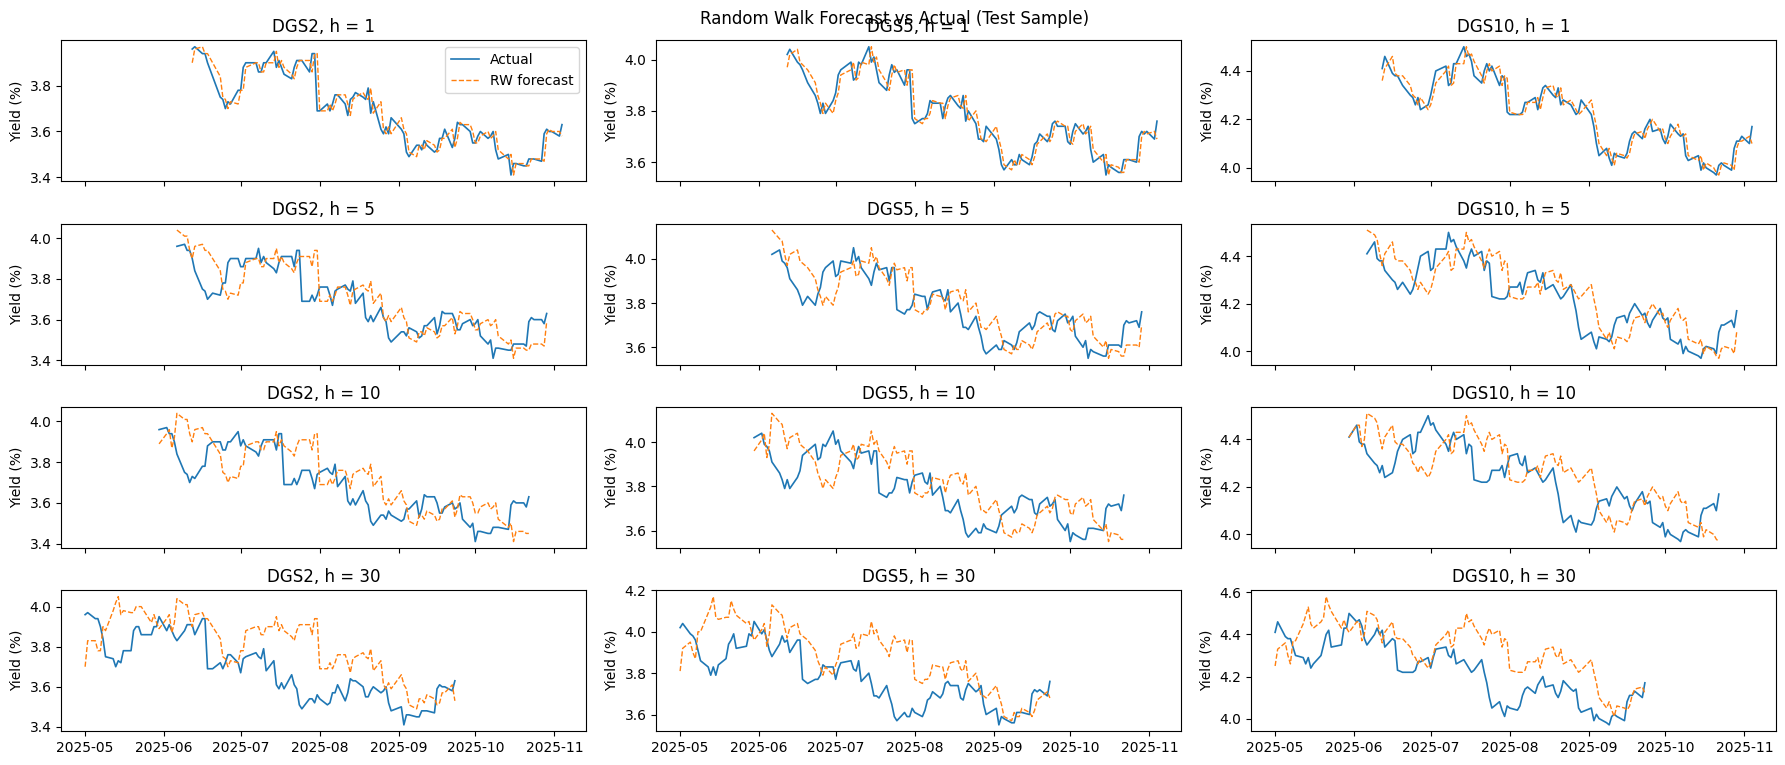

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------Setting up date maturities, hoirzons and test period dates--------------
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

idx = merged.index

# -----------Setting up the Random Walk forecast-------------
results = []


rw_predictions = {}  # keys: (maturity, h) -> pd.Series
rw_actuals     = {}  # same shape as above

for col in maturity_cols:
    y = merged[col]

    for h in horizons:
        # Random walk: y_hat_{t+h|t} = y_t
        forecast = y.copy()
        actual   = y.shift(-h)  # align so index t has actual y_{t+h}

        # Restrict to test window
        mask_test = (idx >= test_start) & (idx <= test_end)
        actual_test = actual.loc[mask_test].dropna()

        # Align forecast with the same timestamps as actual_test
        forecast_test = forecast.loc[actual_test.index]

        # Forecast error: e_t = y_{t+h} - y_t
        errors = actual_test - forecast_test

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err
        })

        rw_predictions[(col, h)] = forecast_test
        rw_actuals[(col, h)] = actual_test

# ------------ Here we store the results in a table ---------------
rw_results_df = pd.DataFrame(results)
rw_results_df = rw_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("Random Walk performance (test period only):")
display(rw_results_df)

# ------------------Create a visualization of the forecast and the real yield ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]

        actual_series = rw_actuals[(col, h)]
        pred_series   = rw_predictions[(col, h)]

        
        N = 100 # Set N to the amount of last observations we want to plot
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="RW forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Random Walk Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()


Our results are as expected.

-Increasing Maturity reduces the RMSE -> more persistence in longer yields

-Increasing forecast horizons increases the RMSE -> more volatility over long periods

-Maturities are ordered DGS2 > DGS 5 > DGS 10 -> longer yields, more persistence

# Implement the Dynamic Nelson Siegel Model

[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): 0.000000

=== Running DNS VAR(1) forecasts for horizon h = 1 ===


/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss


=== Running DNS VAR(1) forecasts for horizon h = 5 ===


/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss


=== Running DNS VAR(1) forecasts for horizon h = 10 ===


...


=== Running DNS VAR(1) forecasts for horizon h = 30 ===


/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss


=== Safety log (first 5 forecasts per horizon) ===

Horizon h = 1:
  origin: 2019-01-02, forecast: 2019-01-03, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-04, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-07, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-08, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-09, train_size: 2506

Horizon h = 5:
  origin: 2019-01-02, forecast: 2019-01-09, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-10, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-11, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-14, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-15, train_size: 2506

Horizon h = 10:
  origin: 2019-01-02, forecast: 2019-01-16, train_size: 2502
  origin: 2019-01-03, forecast: 2019-01-17, train_size: 2503
  origin: 2019-01-04, forecast: 2019-01-18, train_size: 2504
  origin: 2019-01-07, forecast: 2019-01-22, train_size: 2505
  origin: 2019-01-08, forecast: 2019-01-23, t

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss/Desktop/Studium/Semester/7. Semester/Bachelorarbeit/yield-curve-forecasting/yield-curve-forecasting/.venv/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning:

A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.

/Users/chriss

RMSE  Mean_Error  Std_Error  N_Forecasts
Maturity Horizon                                              
DGS10    1        0.059245    0.000199   0.059262         1712
         5        0.128081    0.000851   0.128116         1708
         10       0.182242    0.001227   0.182291         1703
         30       0.339475    0.003708   0.339555         1683
DGS2     1        0.061480   -0.000033   0.061498         1712
         5        0.132357   -0.000241   0.132396         1708
         10       0.191194   -0.000919   0.191248         1703
         30       0.367639   -0.003092   0.367736         1683
DGS5     1        0.062830    0.000239   0.062848         1712
         5        0.135585    0.001062   0.135620         1708
         10       0.193593    0.001681   0.193642         1703
         30       0.363303    0.004613   0.363381         1683

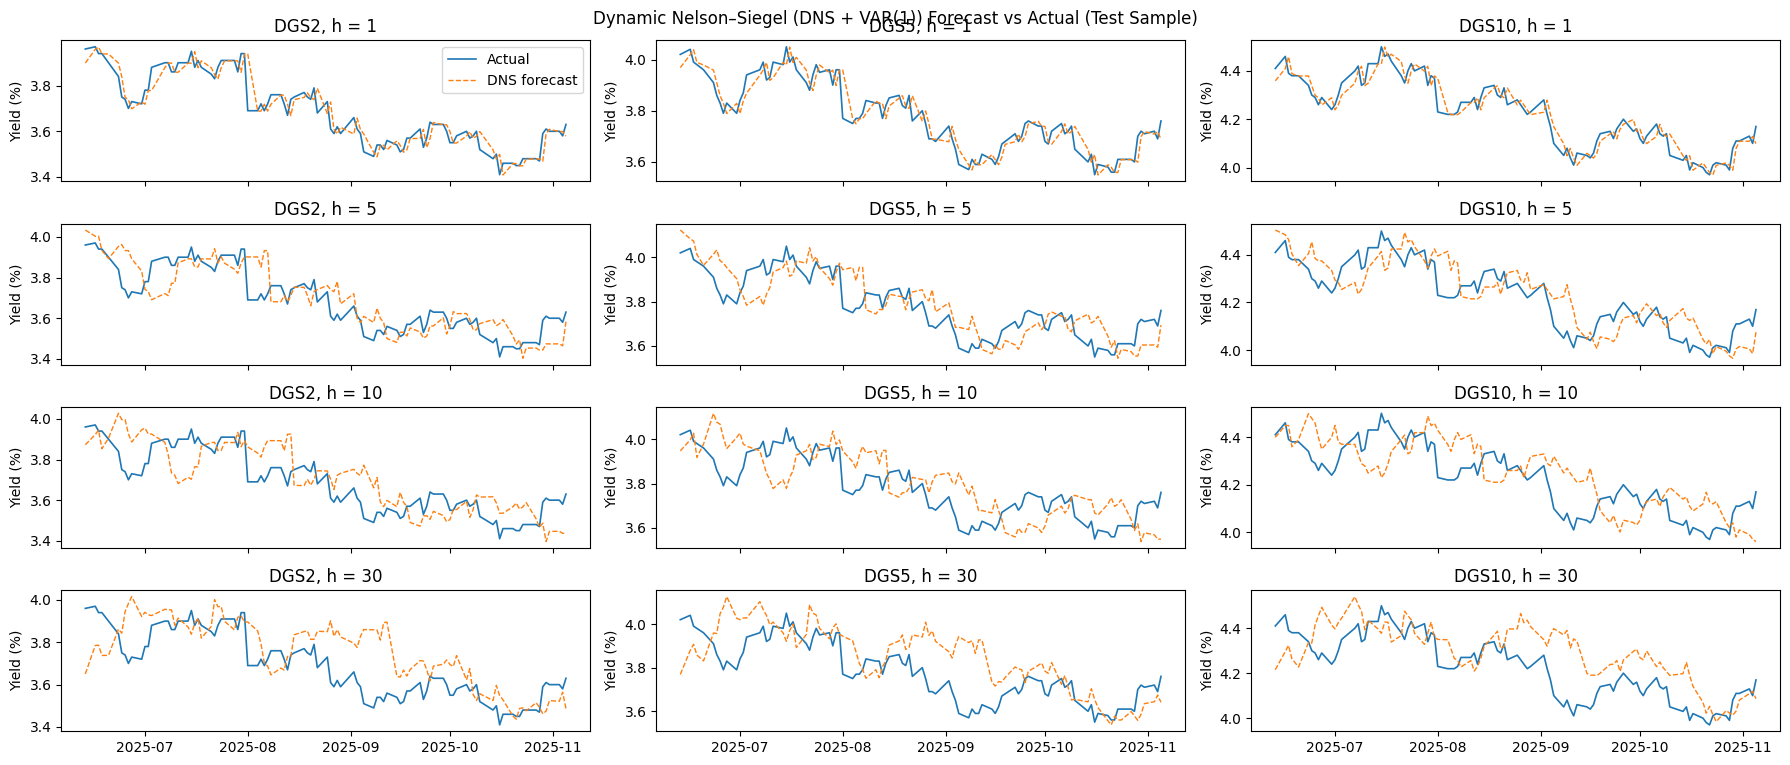

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.api import VAR


# Prepare settings, Fixed Lambda
maturity_cols = ["DGS2", "DGS5", "DGS10"]
tau_years = np.array([2.0, 5.0, 10.0])  # maturities in years
lmbda = 0.0609

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

horizons = [1, 5, 10, 30]


merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# Quick sanity checks on dates
assert idx[0] <= train_start, "Train start before first data point"
assert idx[-1] >= test_end, "Test end after last data point in merged"

# ------------------- Extract DNS factors from yields -------------
def dns_loadings(tau, lam):
    tau = np.asarray(tau, dtype=float)
    one = np.ones_like(tau)
    term = (1 - np.exp(-lam * tau)) / (lam * tau)
    f1 = one
    f2 = term
    f3 = term - np.exp(-lam * tau)
    X = np.column_stack([f1, f2, f3])  # shape (n_maturities, 3)
    return X

# Cross-sectional loading matrix X (constant)
X = dns_loadings(tau_years, lmbda)  # shape (3, 3)

# DNS pseudo-inverse to map yields -> betas
XtX = X.T @ X
assert np.linalg.matrix_rank(XtX) == 3, "X'X is not full rank, DNS inversion fails"

B = np.linalg.inv(XtX) @ X.T  # shape (3, 3)

# Extract betas_t from yields_t (cross-sectional regression at each t)
y_mat = merged[maturity_cols].values  # shape (T, 3)
betas = (y_mat @ B.T)                 # shape (T, 3)

betas_df = pd.DataFrame(
    betas,
    index=merged.index,
    columns=["beta1", "beta2", "beta3"]
)

# Optional internal reconstruction sanity check (no forecasting yet)
y_recon = (betas @ X.T)  # T x 3
recon_rmse = np.sqrt(np.mean((y_mat - y_recon)**2))
print(f"[SANITY] DNS cross-sectional reconstruction RMSE (all sample, all maturities): {recon_rmse:.6f}")

# ------------------- Set up test positions -------------
test_mask = (idx_array >= test_start) & (idx_array <= test_end)
test_positions = np.where(test_mask)[0]
assert len(test_positions) > 0, "No test positions found between test_start and test_end"

last_test_pos = test_positions[-1]

# ------------------- Expanding-window VAR(1) forecasts for betas -------------
dns_pred = {(col, h): {} for col in maturity_cols for h in horizons}

# For safety logging
safety_log = {h: [] for h in horizons}

for h in horizons:
    print(f"\n=== Running DNS VAR(1) forecasts for horizon h = {h} ===")
    
    prev_train_size = 0
    prev_forecast_pos = None

    for pos in test_positions:
        origin_date = idx_array[pos]
        forecast_pos = pos + h

        # If we do not have y_{t+h} inside test window, skip
        if forecast_pos > last_test_pos:
            continue
        
        forecast_date = idx_array[forecast_pos]

       #------------------------- Construct expanding window -------------------------
        train_mask = (idx_array >= train_start) & (idx_array <= origin_date)
        train_betas = betas_df.loc[train_mask]
        train_size = len(train_betas)

        # Harsh safety checks on training window
        assert train_size > 0, "Empty training window, something is wrong"
        assert train_betas.index.min() >= train_start, "Training starts before train_start"
        assert train_betas.index.max() == origin_date, "Training does not end at origin date"
        assert all(train_betas.index <= origin_date), "Training contains observations after origin date (look ahead)"
        assert train_size >= prev_train_size, "Training window is not expanding monotonically"
        prev_train_size = train_size

        # Safety: forecast date must be strictly after origin date
        assert forecast_date > origin_date, "Forecast date is not strictly after origin date"

        # Safety: forecast date must be in test window
        assert (forecast_date >= test_start) and (forecast_date <= test_end), \
            f"Forecast date {forecast_date} outside test window"

        # Safety: monotonic forecast positions
        if prev_forecast_pos is not None:
            assert forecast_pos > prev_forecast_pos, "Forecast positions not strictly increasing"
        prev_forecast_pos = forecast_pos

        # ------------------------- Fit VAR(1) and forecast betas -------------------------
        var_model = VAR(train_betas)
        var_res = var_model.fit(maxlags=1)

        # Safety: we really fitted VAR(1)
        assert var_res.k_ar == 1, f"Expected VAR(1), got VAR({var_res.k_ar})"

        lag_order = var_res.k_ar
        beta_hist = train_betas.values[-lag_order:]  # last k_ar observations

        # h-step-ahead forecast path
        beta_forecast_path = var_res.forecast(beta_hist, steps=h)
        assert beta_forecast_path.shape == (h, 3), "Unexpected beta forecast shape"

        beta_forecast_h = beta_forecast_path[-1]  # horizon-h forecast

        # Map betas back into yields
        y_hat_vec = X @ beta_forecast_h  # length 3

        # Save predictions per maturity
        for j, col in enumerate(maturity_cols):
            dns_pred[(col, h)][forecast_date] = y_hat_vec[j]

        # Log first few entries for manual inspection
        if len(safety_log[h]) < 5:
            safety_log[h].append({
                "origin_date": pd.Timestamp(origin_date),
                "forecast_date": pd.Timestamp(forecast_date),
                "train_size": train_size
            })

# Show safety sample
print("\n=== Safety log (first 5 forecasts per horizon) ===")
for h in horizons:
    print(f"\nHorizon h = {h}:")
    if len(safety_log[h]) == 0:
        print("  (no entries logged)")
    else:
        for entry in safety_log[h]:
            print(
                f"  origin: {entry['origin_date'].date()}, "
                f"forecast: {entry['forecast_date'].date()}, "
                f"train_size: {entry['train_size']}"
            )

# -------------------------- Convert predictions to series and align with actuals -------------------------
dns_pred_series = {}
dns_actual_series = {}

for (col, h), pred_dict in dns_pred.items():
    if len(pred_dict) == 0:
        continue

    pred_s = pd.Series(pred_dict).sort_index()
    # Actual yields at the forecast dates
    actual_s = merged[col].loc[pred_s.index]

    # Safety: indices must match exactly
    assert pred_s.index.equals(actual_s.index), "Predictions and actuals indices do not match"
    # Safety: all dates inside test window
    assert all((pred_s.index >= test_start) & (pred_s.index <= test_end)), \
        "Prediction indices outside test window"

    # Safety: earliest prediction must not be before training start
    assert pred_s.index.min() > train_start, "Earliest prediction before training start"

    dns_pred_series[(col, h)] = pred_s
    dns_actual_series[(col, h)] = actual_s

# -------------------------- Evaluate DNS (VAR(1)) forecasts -------------------------
results = []

for (col, h), pred_s in dns_pred_series.items():
    actual_s = dns_actual_series[(col, h)]
    errors = actual_s - pred_s

    rmse = np.sqrt(np.mean(errors**2))
    mean_err = errors.mean()
    std_err = errors.std(ddof=1)

    results.append({
        "Maturity": col,
        "Horizon": h,
        "RMSE": rmse,
        "Mean_Error": mean_err,
        "Std_Error": std_err,
        "N_Forecasts": len(errors)
    })

dns_results_df = pd.DataFrame(results)
dns_results_df = dns_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nDNS (VAR(1)) performance (test period):")
display(dns_results_df)

# ------------------Create a visualization of the DNS (VAR(1)) forecast and the real yield ------------------
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 8),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]

        key = (col, h)
        if key not in dns_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = dns_actual_series[key]
        pred_series   = dns_pred_series[key]

        # Optional: zoom into last N observations
        N = 100
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="DNS forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Dynamic Nelson–Siegel (DNS + VAR(1)) Forecast vs Actual (Test Sample)", y=0.95)
plt.tight_layout()
plt.show()


Our results are as expected

-DNS underperforms RW over all maturities and horizons. RW is very hard to beat for so short lived periods

-But the difference is very small meaning the DNS model seems to captures important information

-DNS is just a "sophisticated" RW model 

# Examine if there are periods where DNS outperforms RW

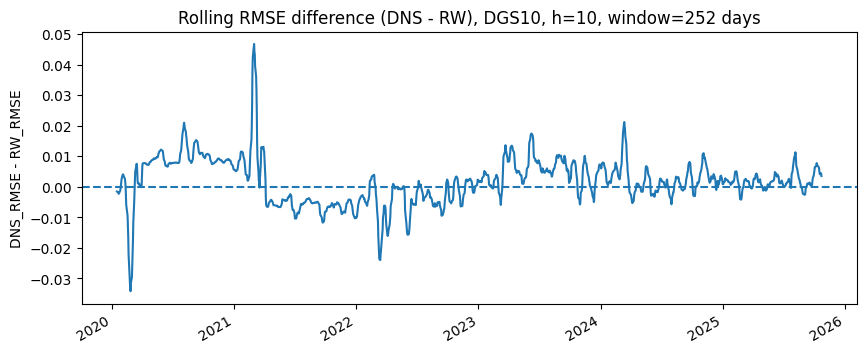

In [18]:
window = 252  # e.g., 1-year rolling window

col = "DGS10"
h   = 10

rw_pred  = rw_predictions[(col, h)]
rw_act   = rw_actuals[(col, h)]
dns_pred = dns_pred_series[(col, h)]
dns_act  = dns_actual_series[(col, h)]

common_idx = rw_pred.index.intersection(dns_pred.index).intersection(rw_act.index).intersection(dns_act.index)
rw_pred  = rw_pred.loc[common_idx]
rw_act   = rw_act.loc[common_idx]
dns_pred = dns_pred.loc[common_idx]
dns_act  = dns_act.loc[common_idx]

rw_se  = (rw_act - rw_pred)**2
dns_se = (dns_act - dns_pred)**2

diff_rmse_rolling = (dns_se.rolling(window).mean()**0.5) - (rw_se.rolling(window).mean()**0.5)

diff_rmse_rolling.plot(figsize=(10, 4))
plt.axhline(0, linestyle="--")
plt.title(f"Rolling RMSE difference (DNS - RW), {col}, h={h}, window={window} days")
plt.ylabel("DNS_RMSE - RW_RMSE")
plt.show()


We see there is no time where DNS consistently beats RW over 252 days. Only short spikes and a lot of time close to zero meaning no significant edge

# Build the Ridge Model

# Search best set of hyperparameters alpha and p (ONLY RUN THIS ONCE AND THEN SAVE PARAMTERS)

In [ ]:
# import numpy as np
# import pandas as pd
# import matplotlib.pyplot as plt

# from sklearn.linear_model import Ridge
# from sklearn.preprocessing import StandardScaler
# from sklearn.pipeline import Pipeline
# from sklearn.base import clone

# # =====================================================
# # 0. Settings
# # =====================================================
# maturity_cols = ["DGS2", "DGS5", "DGS10"]
# horizons = [1, 5, 10, 30]

# train_start = pd.Timestamp("2009-01-02")
# train_end   = pd.Timestamp("2018-12-31")

# # Inner "CV validation" period (within training sample)
# cv_test_start = pd.Timestamp("2014-01-02")  # last ~5 years of train
# cv_test_end   = train_end

# min_train_size = 252  # at least ~1y of data to fit

# merged = merged.sort_index()

# # =====================================================
# # 1. Extended hyperparameter grids
# #    - More values below 0.1 because best was at the lower bound
# #    - Some values above 100 in case stronger shrinkage helps
# #    - More lag lengths around previous extremes (5, 60)
# # =====================================================
# alpha_grid = [
#     0.01, 0.03, 0.1,
#     0.15
# ]

# p_grid = [5, 10, 60, 90, 120]   # lag length candidates

# print("Alpha grid:", alpha_grid)
# print("Lag grid (p):", p_grid)

# # =====================================================
# # 2. Helper: build lagged dataset for given target/horizon/p
# # =====================================================
# def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
#     """
#     Features: yields of all maturities with lags 0..max_lag
#     Target: target_col yield h steps ahead
#     Index: origin dates t (information set)
#     """
#     df = merged[maturity_cols].copy()

#     for m in maturity_cols:
#         for lag in range(0, max_lag + 1):
#             df[f"{m}_lag{lag}"] = merged[m].shift(lag)

#     df["target"] = merged[target_col].shift(-horizon)
#     df = df.dropna()

#     feature_cols = [c for c in df.columns if c.startswith("DGS") and "lag" in c]
#     X = df[feature_cols].values
#     y = df["target"].values
#     dates = df.index

#     return X, y, dates

# # =====================================================
# # 3. Helper: expanding-window Ridge consistent with DNS/RW
# # =====================================================
# def expanding_window_ridge_consistent(
#     X, y, dates, horizon,
#     train_start, test_start, test_end,
#     base_model, target_series,
#     min_train_size=252
# ):
#     """
#     - origin dates are restricted to test_start..test_end (like DNS/RW)
#     - forecast at t+h is evaluated only if t+h <= test_end
#     - predictions are stored at forecast dates and aligned with target_series
#     """
#     dates = pd.DatetimeIndex(dates)

#     # Map dataset dates -> row index in X, y
#     ds_idx_map = {d: i for i, d in enumerate(dates)}

#     idx = merged.index
#     idx_array = np.array(idx)
#     test_mask = (idx_array >= test_start) & (idx_array <= test_end)
#     test_positions = np.where(test_mask)[0]
#     if len(test_positions) == 0:
#         return None, None

#     last_test_pos = test_positions[-1]
#     pred_dict = {}

#     for pos in test_positions:
#         origin_date = idx[pos]

#         # origin date must be present in the supervised dataset
#         if origin_date not in ds_idx_map:
#             continue

#         forecast_pos = pos + horizon
#         if forecast_pos > last_test_pos:
#             continue

#         forecast_date = idx[forecast_pos]

#         # Expanding training window in dataset time
#         train_mask_ds = (dates >= train_start) & (dates <= origin_date)
#         train_idx_ds = np.where(train_mask_ds)[0]

#         if len(train_idx_ds) < min_train_size:
#             continue

#         X_train, y_train = X[train_idx_ds], y[train_idx_ds]

#         origin_row = ds_idx_map[origin_date]
#         X_origin = X[origin_row:origin_row+1]

#         model = clone(base_model)
#         model.fit(X_train, y_train)
#         y_hat = model.predict(X_origin)[0]

#         pred_dict[forecast_date] = y_hat

#     if len(pred_dict) == 0:
#         return None, None

#     pred_s = pd.Series(pred_dict).sort_index()
#     actual_s = target_series.loc[pred_s.index]

#     return pred_s, actual_s

# # =====================================================
# # 4. Time-series CV over extended alpha and p (inside training period)
# # =====================================================
# cv_rows = []

# for target_col in maturity_cols:
#     target_series_full = merged[target_col]

#     for h in horizons:
#         print(f"\n=== CV for Ridge: target={target_col}, h={h} ===")

#         for p in p_grid:
#             X, y, dates = build_lagged_dataset(
#                 merged=merged,
#                 maturity_cols=maturity_cols,
#                 target_col=target_col,
#                 horizon=h,
#                 max_lag=p
#             )

#             # Restrict dataset to dates <= train_end (we don't want to peek into OOS)
#             mask_in_train = dates <= train_end
#             X_train_ds = X[mask_in_train]
#             y_train_ds = y[mask_in_train]
#             dates_train_ds = dates[mask_in_train]

#             if len(dates_train_ds) < min_train_size + 50:
#                 print(f"  Skipping p={p}: not enough data.")
#                 continue

#             for alpha in alpha_grid:
#                 ridge_pipeline = Pipeline([
#                     ("scaler", StandardScaler()),
#                     ("ridge", Ridge(alpha=alpha))
#                 ])

#                 # Use expanding window within [train_start .. train_end],
#                 # validated on [cv_test_start .. cv_test_end]
#                 pred_s, actual_s = expanding_window_ridge_consistent(
#                     X=X_train_ds,
#                     y=y_train_ds,
#                     dates=dates_train_ds,
#                     horizon=h,
#                     train_start=train_start,
#                     test_start=cv_test_start,
#                     test_end=cv_test_end,
#                     base_model=ridge_pipeline,
#                     target_series=target_series_full,
#                     min_train_size=min_train_size
#                 )

#                 if pred_s is None:
#                     print(f"  (alpha={alpha}, p={p}) produced no forecasts.")
#                     continue

#                 errors = actual_s - pred_s
#                 rmse = np.sqrt(np.mean(errors**2))

#                 cv_rows.append({
#                     "Maturity": target_col,
#                     "Horizon": h,
#                     "alpha": alpha,
#                     "p": p,
#                     "CV_RMSE": rmse,
#                     "N_Forecasts": len(errors)
#                 })

# ridge_cv_results = pd.DataFrame(cv_rows)
# ridge_cv_results = ridge_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

# print("\nRidge CV results (first rows):")
# display(ridge_cv_results.head())

# # =====================================================
# # 5. Choose best (alpha, p) per (Maturity, Horizon)
# # =====================================================
# ridge_best_params = {}

# for (mat, h), group in ridge_cv_results.groupby(level=[0,1]):
#     best_row = group.sort_values("CV_RMSE").iloc[0]
#     ridge_best_params[(mat, h)] = {
#         "alpha": best_row["alpha"],
#         "p": int(best_row["p"]),
#         "CV_RMSE": best_row["CV_RMSE"],
#         "N_Forecasts": int(best_row["N_Forecasts"])
#     }

# print("\nBest Ridge hyperparameters per (Maturity, Horizon):")
# for key, val in ridge_best_params.items():
#     mat, h = key
#     print(
#         f"  {mat}, h={h}: alpha={val['alpha']}, p={val['p']}, "
#         f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
#     )


Alpha grid: [0.01, 0.03, 0.1, 0.15]
Lag grid (p): [5, 10, 60, 90, 120]

=== CV for Ridge: target=DGS2, h=1 ===


C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 


=== CV for Ridge: target=DGS2, h=5 ===


C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 


=== CV for Ridge: target=DGS2, h=10 ===


...


=== CV for Ridge: target=DGS10, h=30 ===


C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

C:\Users\mango\AppData\Local\Temp\ipykernel_2112\1382283660.py:56: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented 


Ridge CV results (first rows):


alpha   p   CV_RMSE  N_Forecasts
Maturity Horizon                                  
DGS10    1         0.01   5  0.041843         1249
         1         0.03   5  0.041843         1249
         1         0.10   5  0.041846         1249
         1         0.15   5  0.041850         1249
         1         0.01  10  0.042050         1249


Best Ridge hyperparameters per (Maturity, Horizon):
  DGS10, h=1: alpha=0.1, p=120, CV_RMSE=0.039997, N=1249
  DGS10, h=5: alpha=0.01, p=120, CV_RMSE=0.086183, N=1245
  DGS10, h=10: alpha=0.01, p=90, CV_RMSE=0.119180, N=1240
  DGS10, h=30: alpha=0.01, p=90, CV_RMSE=0.192183, N=1220
  DGS2, h=1: alpha=0.01, p=120, CV_RMSE=0.027172, N=1249
  DGS2, h=5: alpha=0.01, p=120, CV_RMSE=0.056857, N=1245
  DGS2, h=10: alpha=0.01, p=120, CV_RMSE=0.079240, N=1240
  DGS2, h=30: alpha=0.01, p=90, CV_RMSE=0.124276, N=1220
  DGS5, h=1: alpha=0.03, p=120, CV_RMSE=0.039130, N=1249
  DGS5, h=5: alpha=0.01, p=120, CV_RMSE=0.086121, N=1245
  DGS5, h=10: alpha=0.01, p=120, CV_RMSE=0.120739, N=1240
  DGS5, h=30: alpha=0.01, p=90, CV_RMSE=0.188103, N=1220


# Saving best paramters to save time

In [5]:
ridge_best_params = {
    ("DGS10", 1):  {"alpha": 0.1,  "p": 120},
    ("DGS10", 5):  {"alpha": 0.01, "p": 120},
    ("DGS10", 10): {"alpha": 0.01, "p": 90},
    ("DGS10", 30): {"alpha": 0.01, "p": 90},

    ("DGS2", 1):   {"alpha": 0.01, "p": 120},
    ("DGS2", 5):   {"alpha": 0.01, "p": 120},
    ("DGS2", 10):  {"alpha": 0.01, "p": 120},
    ("DGS2", 30):  {"alpha": 0.01, "p": 90},

    ("DGS5", 1):   {"alpha": 0.03, "p": 120},
    ("DGS5", 5):   {"alpha": 0.01, "p": 120},
    ("DGS5", 10):  {"alpha": 0.01, "p": 120},
    ("DGS5", 30):  {"alpha": 0.01, "p": 90},
}


# Train Ridge on best set of hyperparameters

Running Ridge forecasts for DGS2, h = 1, alpha=0.01, p=120 ...


/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

Running Ridge forecasts for DGS2, h = 5, alpha=0.01, p=120 ...


/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

Running Ridge forecasts for DGS2, h = 10, alpha=0.01, p=120 ...


...

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co

Running Ridge forecasts for DGS10, h = 30, alpha=0.01, p=90 ...


/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`

/var/folders/b0/vnw_t5qn7zdccn_qsc7_4cs40000gn/T/ipykernel_18676/678309812.py:43: PerformanceWarning:

DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.co


Ridge (expanding window, tuned hyperparameters) performance (test period):


RMSE  Mean_Error  Std_Error  N_Forecasts  alpha    p
Maturity Horizon                                                          
DGS10    1        0.052553    0.000109   0.052568         1712   0.10  120
         5        0.113165    0.000370   0.113198         1708   0.01  120
         10       0.167743    0.007684   0.167616         1703   0.01   90
         30       0.301920    0.020039   0.301344         1683   0.01   90
DGS2     1        0.051626    0.000701   0.051636         1712   0.01  120
         5        0.110825    0.003323   0.110808         1708   0.01  120
         10       0.161084    0.007070   0.160976         1703   0.01  120
         30       0.311197    0.024528   0.310322         1683   0.01   90
DGS5     1        0.054527    0.000486   0.054541         1712   0.03  120
         5        0.116932    0.002250   0.116944         1708   0.01  120
         10       0.168780    0.004812   0.168760         1703   0.01  120
         30       0.319603    0.025737   0.318659         1683   0.01   90

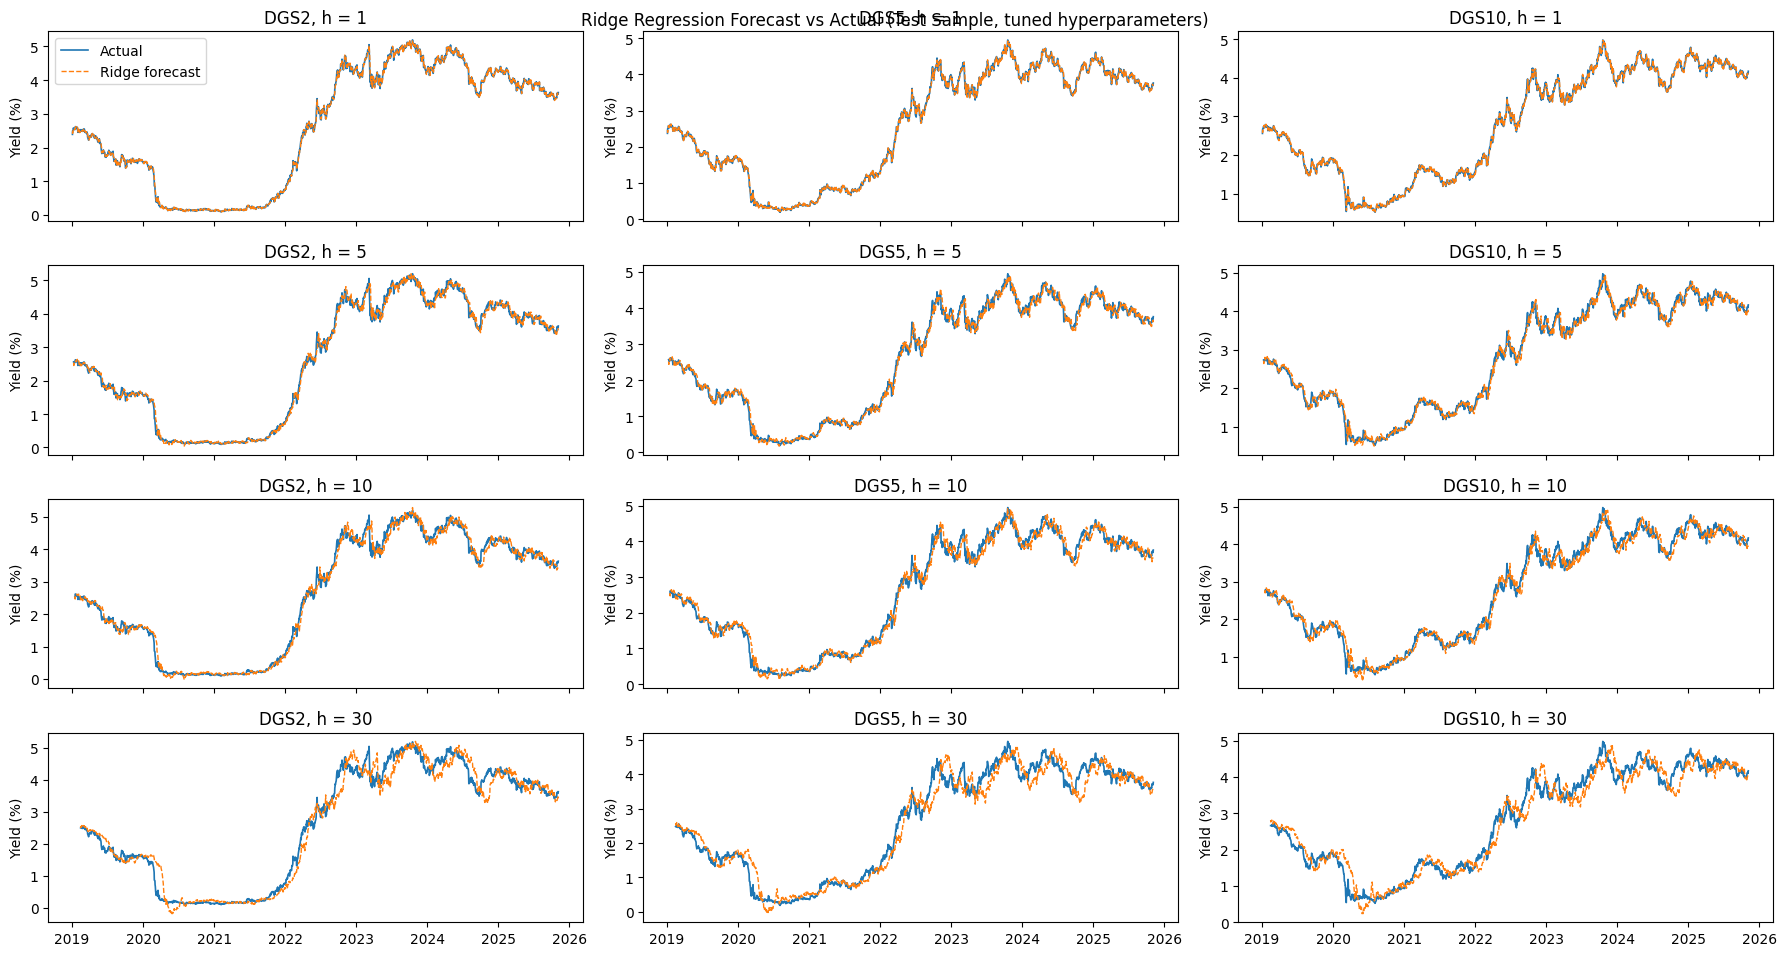

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

min_train_size = 252  # require at least ~1 year of data to fit

merged = merged.sort_index()
idx = merged.index
idx_array = np.array(idx)

# =====================================================
# 1. Supervised dataset builder (lags + horizon)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    Creates a supervised dataset for a given target maturity and horizon.
    Features: yields of all maturities with lags 0..max_lag
    Target:   target_col yield h steps ahead (same as DNS / RW horizon)
    Index:    origin date t (the date we observe features up to)
    """
    df = merged[maturity_cols].copy()

    # Add lag features
    for m in maturity_cols:
        for lag in range(0, max_lag + 1):
            df[f"{m}_lag{lag}"] = merged[m].shift(lag)

    # Target: yield at t+h
    df["target"] = merged[target_col].shift(-horizon)

    # Drop rows with any NaNs (from lags or shifting)
    df = df.dropna()

    # Features and target
    feature_cols = [c for c in df.columns if c.startswith("DGS") and "lag" in c]
    X = df[feature_cols].values
    y = df["target"].values
    dates = df.index  # origin dates t

    return X, y, dates

# =====================================================
# 2. Expanding window forecasting function (aligned with DNS/RW)
# =====================================================
def expanding_window_ridge(X, y, dates, horizon,
                           train_start, test_start, test_end,
                           base_model, target_series,
                           min_train_size=252):
    """
    Expanding-window Ridge, aligned with DNS/RW:
    - origin dates restricted to test window
    - last h days dropped (no room for t+h inside test window)
    Predictions are stored at forecast dates (t+h) and aligned with target_series.
    """
    dates = pd.DatetimeIndex(dates)

    # Map origin dates in the supervised dataset to row indices
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)
    test_mask = (idx_array >= test_start) & (idx_array <= test_end)
    test_positions = np.where(test_mask)[0]
    if len(test_positions) == 0:
        return None, None

    last_test_pos = test_positions[-1]
    pred_dict = {}

    for pos in test_positions:
        origin_date = idx[pos]

        # origin date must be present in the supervised dataset
        if origin_date not in ds_idx_map:
            continue

        forecast_pos = pos + horizon
        if forecast_pos > last_test_pos:
            # drop last h-1 days
            continue

        forecast_date = idx[forecast_pos]

        # Expanding training window on supervised data
        train_mask_ds = (dates >= train_start) & (dates <= origin_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        model = clone(base_model)
        model.fit(X_train, y_train)
        y_hat = model.predict(X_origin)[0]

        pred_dict[forecast_date] = y_hat

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    # align with actual target series (e.g. merged[target_col])
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 3. Final Ridge evaluation with tuned hyperparameters
#    (ridge_best_params must exist from the CV cell)
# =====================================================

ridge_pred_series = {}
ridge_actual_series = {}
results = []

for target_col in maturity_cols:
    target_series_full = merged[target_col]

    for h in horizons:
        # fetch best alpha and p from CV step
        best = ridge_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        alpha  = best["alpha"]
        max_lag = best["p"]

        print(f"Running Ridge forecasts for {target_col}, h = {h}, "
              f"alpha={alpha}, p={max_lag} ...")

        # Build supervised dataset with the chosen lag length p
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=max_lag
        )

        # Define Ridge pipeline with the chosen alpha
        ridge_pipeline = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha))
        ])

        # Run expanding-window Ridge forecasting
        pred_s, actual_s = expanding_window_ridge(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_model=ridge_pipeline,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        # Align and compute errors
        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "alpha": alpha,
            "p": max_lag
        })

        ridge_pred_series[(target_col, h)] = pred_s
        ridge_actual_series[(target_col, h)] = actual_s

# =====================================================
# 4. Results table
# =====================================================
ridge_results_df = pd.DataFrame(results)
ridge_results_df = ridge_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nRidge (expanding window, tuned hyperparameters) performance (test period):")
display(ridge_results_df)

# =====================================================
# 5. Visualization: actual vs Ridge forecast (last part of test sample)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in ridge_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = ridge_actual_series[key]
        pred_series   = ridge_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="Ridge forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("Ridge Regression Forecast vs Actual (Test Sample, tuned hyperparameters)", y=0.95)
plt.tight_layout()
plt.show()


# Comparative Plot of the different predictions for changable horizons and business days

In [7]:
import matplotlib.pyplot as plt

col = "DGS5"
h = 30
N = 500  # number of last observations to show

# Take actuals from Ridge (same index as DNS)
actual = ridge_actual_series[(col, h)].copy()

# Model predictions in forecast-date space
ridge_pred = ridge_pred_series[(col, h)].reindex(actual.index)
dns_pred   = dns_pred_series[(col, h)].reindex(actual.index)

# RW forecast in forecast-date space: y_hat_F = y_{F-h}
rw_pred = merged[col].shift(h).loc[actual.index]

# (Optional) check alignment
# print(actual.index[-5:], rw_pred.index[-5:], dns_pred.index[-5:], ridge_pred.index[-5:])

# Now restrict to last N forecast dates
idx = actual.index[-N:]

plt.figure(figsize=(10, 4))

plt.plot(idx, actual.loc[idx],     label="Actual", linewidth=1.5)
plt.plot(idx, rw_pred.loc[idx],    label="RW", linestyle="--", linewidth=1.0)
plt.plot(idx, dns_pred.loc[idx],   label="DNS", linestyle="--", linewidth=1.0)
plt.plot(idx, ridge_pred.loc[idx], label="Ridge", linestyle="--", linewidth=1.0)
# later: XGBoost etc.

plt.ylabel("Yield (%)")
plt.xlabel("")
plt.title("30-Day-Ahead Forecasts for 5-Year Yield (DGS5, last 100 business days)")
plt.legend()
plt.tight_layout()
plt.show()


NameError: name 'dns_pred_series' is not defined

# XGBoost Implementation

# Find best set up Hyperparameter (Learning rate, max_depth, n_estimators, lag length for input features). Only run this once and then save donw below

In [ ]:
import numpy as np
import pandas as pd
from xgboost import XGBRegressor

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

# Inner CV validation window (inside training sample, like Ridge)
cv_test_start = pd.Timestamp("2014-01-02")
cv_test_end   = train_end

min_train_size = 252  # at least ~1 year of data

merged = merged.sort_index()

# ----- GPU / CPU toggle -----
USE_GPU = True  # set this to True on your RTX 2060 machine, False on CPU-only
if USE_GPU:
    tree_method = "gpu_hist"  # works with recent xgboost + CUDA
else:
    tree_method = "hist"

# =====================================================
# 1. Helper: build lagged dataset for given target/horizon/p
#    (same structure as Ridge)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    Features: yields of all maturities with lags 0..max_lag
    Target:   target_col yield h steps ahead
    Index:    origin dates t
    """
    df = merged[maturity_cols].copy()

    for m in maturity_cols:
        for lag in range(0, max_lag + 1):
            df[f"{m}_lag{lag}"] = merged[m].shift(lag)

    df["target"] = merged[target_col].shift(-horizon)
    df = df.dropna()

    feature_cols = [c for c in df.columns if c.startswith("DGS") and "lag" in c]
    X = df[feature_cols].values
    y = df["target"].values
    dates = df.index

    return X, y, dates

# =====================================================
# 2. Helper: expanding-window forecasting (aligned with Ridge/DNS/RW)
# =====================================================
def expanding_window_xgb_consistent(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_model, target_series,
    min_train_size=252
):
    """
    - origin dates restricted to [test_start, test_end] in calendar time
    - for each origin, train on [train_start, origin_date] in dataset time
    - forecast at forecast_date = origin_date shifted by h in merged index
    - predictions stored at forecast dates and aligned with target_series
    """
    dates = pd.DatetimeIndex(dates)

    # Map dataset dates -> row index in X, y
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origins in calendar time (like Ridge)
    test_mask = (idx_array >= test_start) & (idx_array <= test_end)
    test_positions = np.where(test_mask)[0]
    if len(test_positions) == 0:
        return None, None

    last_test_pos = test_positions[-1]
    pred_dict = {}

    for pos in test_positions:
        origin_date = idx[pos]

        # origin date must exist in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        forecast_pos = pos + horizon
        if forecast_pos > last_test_pos:
            # drop last h-1 days
            continue

        forecast_date = idx[forecast_pos]

        # Expanding training window in dataset time
        train_mask_ds = (dates >= train_start) & (dates <= origin_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        model = XGBRegressor(**base_model.get_params())
        model.fit(X_train, y_train)
        y_hat = model.predict(X_origin)[0]

        pred_dict[forecast_date] = y_hat

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s

# =====================================================
# 3. Lighter hyperparameter grid (desktop-friendly)
# =====================================================
# You can enlarge this later if your desktop is fast enough.
p_grid            = [20, 60]       # lag length candidates
eta_grid          = [0.05, 0.1]    # learning rate
max_depth_grid    = [2, 3]         # tree depth
n_estimators_grid = [200, 400]     # number of trees

# =====================================================
# 4. Time-series CV over XGBoost hyperparameters
# =====================================================
cv_rows = []

for target_col in maturity_cols:
    target_series_full = merged[target_col]

    for h in horizons:
        print(f"\n=== XGBoost CV: target={target_col}, h={h} ===")

        for p in p_grid:
            # Build supervised dataset for this lag length
            X, y, dates = build_lagged_dataset(
                merged=merged,
                maturity_cols=maturity_cols,
                target_col=target_col,
                horizon=h,
                max_lag=p
            )

            # Restrict dataset to training sample only (no future info)
            mask_in_train = dates <= train_end
            X_train_ds = X[mask_in_train]
            y_train_ds = y[mask_in_train]
            dates_train_ds = dates[mask_in_train]

            if len(dates_train_ds) < min_train_size + 50:
                print(f"  Skipping p={p}: not enough data.")
                continue

            for eta in eta_grid:
                for max_depth in max_depth_grid:
                    for n_estimators in n_estimators_grid:
                        print(
                            f"  p={p}, eta={eta}, depth={max_depth}, "
                            f"n_estimators={n_estimators}"
                        )

                        xgb_model = XGBRegressor(
                            objective="reg:squarederror",
                            learning_rate=eta,
                            max_depth=max_depth,
                            n_estimators=n_estimators,
                            subsample=0.7,
                            colsample_bytree=0.7,
                            min_child_weight=1,
                            reg_lambda=1.0,
                            random_state=42,
                            n_jobs=-1,
                            tree_method=tree_method,
                        )

                        # Expanding-window CV within [cv_test_start, cv_test_end]
                        pred_s, actual_s = expanding_window_xgb_consistent(
                            X=X_train_ds,
                            y=y_train_ds,
                            dates=dates_train_ds,
                            horizon=h,
                            train_start=train_start,
                            test_start=cv_test_start,
                            test_end=cv_test_end,
                            base_model=xgb_model,
                            target_series=target_series_full,
                            min_train_size=min_train_size
                        )

                        if pred_s is None:
                            print("    -> produced no forecasts, skipping.")
                            continue

                        errors = actual_s - pred_s
                        rmse = np.sqrt(np.mean(errors**2))

                        cv_rows.append({
                            "Maturity": target_col,
                            "Horizon": h,
                            "p": p,
                            "eta": eta,
                            "max_depth": max_depth,
                            "n_estimators": n_estimators,
                            "CV_RMSE": rmse,
                            "N_Forecasts": len(errors)
                        })

# =====================================================
# 5. Collect CV results and select best params
# =====================================================
xgb_cv_results = pd.DataFrame(cv_rows)
if not xgb_cv_results.empty:
    xgb_cv_results = xgb_cv_results.set_index(["Maturity", "Horizon"]).sort_index()

print("\nXGBoost CV results (first rows):")
display(xgb_cv_results.head())

xgb_best_params = {}

if not xgb_cv_results.empty:
    for (mat, h), group in xgb_cv_results.groupby(level=[0, 1]):
        best_row = group.sort_values("CV_RMSE").iloc[0]
        xgb_best_params[(mat, h)] = {
            "p": int(best_row["p"]),
            "eta": float(best_row["eta"]),
            "max_depth": int(best_row["max_depth"]),
            "n_estimators": int(best_row["n_estimators"]),
            "CV_RMSE": float(best_row["CV_RMSE"]),
            "N_Forecasts": int(best_row["N_Forecasts"])
        }

print("\nBest XGBoost hyperparameters per (Maturity, Horizon):")
for key, val in xgb_best_params.items():
    mat, h = key
    print(
        f"  {mat}, h={h}: "
        f"p={val['p']}, eta={val['eta']}, depth={val['max_depth']}, "
        f"n_estimators={val['n_estimators']}, "
        f"CV_RMSE={val['CV_RMSE']:.6f}, N={val['N_Forecasts']}"
    )


# Save best set of hyperparameters here

# Train the final model on the best set up Hyperparameters

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# =====================================================
# 0. Settings
# =====================================================
maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

train_start = pd.Timestamp("2009-01-02")
train_end   = pd.Timestamp("2018-12-31")

test_start  = pd.Timestamp("2019-01-02")
test_end    = pd.Timestamp("2025-11-05")

min_train_size = 252  # at least ~1 year of data

merged = merged.sort_index()
idx = merged.index

# =====================================================
# 1. GPU / CPU toggle
# =====================================================
USE_GPU = True  # set False on MacBook, True on RTX desktop

if USE_GPU:
    tree_method = "gpu_hist"   # GPU-accelerated hist algorithm
else:
    tree_method = "hist"       # CPU version


# =====================================================
# 2. Helper: build lagged dataset (same as Ridge)
# =====================================================
def build_lagged_dataset(merged, maturity_cols, target_col, horizon, max_lag):
    """
    Features: yields of all maturities with lags 0..max_lag
    Target:   target_col yield h steps ahead
    Index:    origin dates t
    """
    df = merged[maturity_cols].copy()

    for m in maturity_cols:
        for lag in range(0, max_lag + 1):
            df[f"{m}_lag{lag}"] = merged[m].shift(lag)

    df["target"] = merged[target_col].shift(-horizon)
    df = df.dropna()

    feature_cols = [c for c in df.columns if c.startswith("DGS") and "lag" in c]
    X = df[feature_cols].values
    y = df["target"].values
    dates = df.index

    return X, y, dates


# =====================================================
# 3. Helper: expanding-window XGBoost (aligned with Ridge/DNS/RW)
# =====================================================
def expanding_window_xgb(
    X, y, dates, horizon,
    train_start, test_start, test_end,
    base_params, target_series,
    min_train_size=252
):
    """
    - origin dates restricted to [test_start, test_end] in calendar time
    - for each origin, train on [train_start, origin_date] in dataset time
    - forecast at forecast_date = origin_date shifted by h in merged index
    - predictions stored at forecast dates and aligned with target_series
    """
    dates = pd.DatetimeIndex(dates)

    # Map dataset dates -> row index in X, y
    ds_idx_map = {d: i for i, d in enumerate(dates)}

    idx = merged.index
    idx_array = np.array(idx)

    # Origins in calendar time
    test_mask = (idx_array >= test_start) & (idx_array <= test_end)
    test_positions = np.where(test_mask)[0]
    if len(test_positions) == 0:
        return None, None

    last_test_pos = test_positions[-1]
    pred_dict = {}

    for pos in test_positions:
        origin_date = idx[pos]

        # origin date must exist in supervised dataset
        if origin_date not in ds_idx_map:
            continue

        forecast_pos = pos + horizon
        if forecast_pos > last_test_pos:
            # drop last h-1 days
            continue

        forecast_date = idx[forecast_pos]

        # Expanding training window in dataset time
        train_mask_ds = (dates >= train_start) & (dates <= origin_date)
        train_idx_ds = np.where(train_mask_ds)[0]

        if len(train_idx_ds) < min_train_size:
            continue

        X_train, y_train = X[train_idx_ds], y[train_idx_ds]

        origin_row = ds_idx_map[origin_date]
        X_origin = X[origin_row:origin_row+1]

        # New XGB model each origin, with fixed tuned params
        model = XGBRegressor(
            objective="reg:squarederror",
            learning_rate=base_params["eta"],
            max_depth=base_params["max_depth"],
            n_estimators=base_params["n_estimators"],
            subsample=0.7,
            colsample_bytree=0.7,
            min_child_weight=1,
            reg_lambda=1.0,
            random_state=42,
            n_jobs=-1,
            tree_method=tree_method,
        )

        model.fit(X_train, y_train)
        y_hat = model.predict(X_origin)[0]

        pred_dict[forecast_date] = y_hat

    if len(pred_dict) == 0:
        return None, None

    pred_s = pd.Series(pred_dict).sort_index()
    actual_s = target_series.loc[pred_s.index]

    return pred_s, actual_s


# =====================================================
# 4. Final XGBoost evaluation (using tuned hyperparameters)
#    xgb_best_params must be defined beforehand, e.g.:
#    xgb_best_params[(maturity, h)] = {"p": ..., "eta": ..., "max_depth": ..., "n_estimators": ...}
# =====================================================

xgb_pred_series = {}
xgb_actual_series = {}
results = []

for target_col in maturity_cols:
    target_series_full = merged[target_col]

    for h in horizons:
        best = xgb_best_params.get((target_col, h), None)
        if best is None:
            print(f"No best params found for {target_col}, h={h}, skipping.")
            continue

        p           = best["p"]
        eta         = best["eta"]
        max_depth   = best["max_depth"]
        n_estimators = best["n_estimators"]

        print(f"Running XGBoost forecasts for {target_col}, h={h} "
              f"(p={p}, eta={eta}, depth={max_depth}, trees={n_estimators}) ...")

        # Build supervised dataset with this lag length
        X, y, dates = build_lagged_dataset(
            merged=merged,
            maturity_cols=maturity_cols,
            target_col=target_col,
            horizon=h,
            max_lag=p
        )

        base_params = {
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        }

        # Run expanding-window XGBoost forecasting
        pred_s, actual_s = expanding_window_xgb(
            X=X,
            y=y,
            dates=dates,
            horizon=h,
            train_start=train_start,
            test_start=test_start,
            test_end=test_end,
            base_params=base_params,
            target_series=target_series_full,
            min_train_size=min_train_size
        )

        if pred_s is None:
            print(f"  -> No forecasts produced for {target_col}, h={h}")
            continue

        errors = actual_s - pred_s

        rmse = np.sqrt(np.mean(errors**2))
        mean_err = errors.mean()
        std_err = errors.std(ddof=1)

        results.append({
            "Maturity": target_col,
            "Horizon": h,
            "RMSE": rmse,
            "Mean_Error": mean_err,
            "Std_Error": std_err,
            "N_Forecasts": len(errors),
            "p": p,
            "eta": eta,
            "max_depth": max_depth,
            "n_estimators": n_estimators
        })

        xgb_pred_series[(target_col, h)] = pred_s
        xgb_actual_series[(target_col, h)] = actual_s

# =====================================================
# 5. Results table
# =====================================================
xgb_results_df = pd.DataFrame(results)
xgb_results_df = xgb_results_df.set_index(["Maturity", "Horizon"]).sort_index()

print("\nXGBoost (expanding window, tuned hyperparameters) performance (test period):")
display(xgb_results_df)


# =====================================================
# 6. Visualization: actual vs XGBoost forecast (same style as Ridge/DNS/RW)
# =====================================================
fig, axes = plt.subplots(
    nrows=len(horizons),
    ncols=len(maturity_cols),
    figsize=(18, 10),
    sharex=True
)

for i, h in enumerate(horizons):
    for j, col in enumerate(maturity_cols):
        ax = axes[i, j] if len(horizons) > 1 else axes[j]
        key = (col, h)

        if key not in xgb_pred_series:
            ax.set_title(f"{col}, h = {h} (no forecasts)")
            continue

        actual_series = xgb_actual_series[key]
        pred_series   = xgb_pred_series[key]

        # Optional: zoom into last N observations
        N = len(actual_series)  # or e.g. 500
        actual_series = actual_series.iloc[-N:]
        pred_series   = pred_series.iloc[-N:]

        ax.plot(actual_series.index, actual_series.values, label="Actual", linewidth=1.2)
        ax.plot(pred_series.index,   pred_series.values,   label="XGBoost forecast", linestyle="--", linewidth=1.0)

        ax.set_title(f"{col}, h = {h}")
        ax.set_xlabel("")
        ax.set_ylabel("Yield (%)")

        if i == 0 and j == 0:
            ax.legend()

plt.suptitle("XGBoost Forecast vs Actual (Test Sample, tuned hyperparameters)", y=0.95)
plt.tight_layout()
plt.show()


# Performance Evaluation

## Diebold-Marino Test

In [ ]:
import numpy as np
from scipy.stats import norm

def dm_test(errors_model1, errors_model2, h=1, lag=None):
    """
    Diebold-Mariano test for equal predictive accuracy (squared-error loss).

    Parameters
    ----------
    errors_model1 : array-like
        Forecast errors of model 1 (y - y_hat1), length N.
    errors_model2 : array-like
        Forecast errors of model 2 (y - y_hat2), length N.
    h : int, optional
        Forecast horizon (in periods). Used only if lag is None.
    lag : int, optional
        Newey-West truncation lag for HAC variance.
        If None, lag is set to max(h-1, 0).

    Returns
    -------
    dm_stat : float
        Diebold-Mariano test statistic.
    p_value : float
        Two-sided p-value under asymptotic N(0,1).
    """

    e1 = np.asarray(errors_model1)
    e2 = np.asarray(errors_model2)

    # Drop NaNs in parallel
    mask = np.isfinite(e1) & np.isfinite(e2)
    e1 = e1[mask]
    e2 = e2[mask]

    if e1.shape != e2.shape:
        raise ValueError("Error series must have the same length after NaN removal.")

    N = len(e1)
    if N < 5:
        raise ValueError("Not enough observations for DM test.")

    # Squared-error loss
    L1 = e1 ** 2
    L2 = e2 ** 2

    # Loss differential
    d = L1 - L2
    d_bar = np.mean(d)

    # Newey–West HAC variance of d_t
    if lag is None:
        lag = max(h - 1, 0)

    d_centered = d - d_bar
    gamma0 = np.dot(d_centered, d_centered) / N
    var_d = gamma0

    for k in range(1, lag + 1):
        cov = np.dot(d_centered[k:], d_centered[:-k]) / N
        weight = 1.0 - k / (lag + 1)  # Bartlett weight
        var_d += 2.0 * weight * cov

    dm_stat = d_bar / np.sqrt(var_d / N)
    p_value = 2 * (1 - norm.cdf(np.abs(dm_stat)))

    return dm_stat, p_value


In [ ]:
# Define your models and their prediction dicts
model_preds = {
    "RW":    rw_pred_series,
    "DNS":   dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGB":   xgb_pred_series,
}

maturity_cols = ["DGS2", "DGS5", "DGS10"]
horizons = [1, 5, 10, 30]

dm_results = []

for maturity in maturity_cols:
    for h in horizons:
        key = (maturity, h)

        # Use one model's actual series as the ground truth (here: XGB)
        if key not in xgb_actual_series:
            # skip if this (maturity, horizon) combination doesn't exist
            continue

        actual = xgb_actual_series[key].copy()

        # Collect errors for each model (aligned by date index)
        errors = {}
        for model_name, pred_dict in model_preds.items():
            if key not in pred_dict:
                continue

            preds = pred_dict[key]

            # Align to common index (intersection with 'actual')
            df_tmp = (
                pd.DataFrame({"actual": actual})
                .join(preds.rename("pred"), how="inner")
                .dropna()
            )

            if df_tmp.empty:
                continue

            err = df_tmp["actual"] - df_tmp["pred"]
            errors[model_name] = err

        # Need at least RW + one other model
        if "RW" not in errors:
            continue

        # Compare each non-RW model against RW
        for model_name, err in errors.items():
            if model_name == "RW":
                continue

            dm_stat, p_val = dm_test(errors["RW"], err, h=h)

            dm_results.append({
                "Maturity": maturity,
                "Horizon": h,
                "Model_1": "RW",
                "Model_2": model_name,
                "DM_stat": dm_stat,
                "p_value": p_val,
                "N": len(errors["RW"])
            })

dm_results_df = pd.DataFrame(dm_results)
dm_results_df = dm_results_df.sort_values(["Maturity", "Horizon", "Model_2"])

print(dm_results_df)


# Economic Value Evaluation

## Trading

Define Helper Functions

In [ ]:
short_rate = DGS1["DGS1"]   # if DGS1 is a DataFrame
# (if DGS1 is already a Series, you can just use: short_rate = DGS1)
maturity_durations = {
    "DGS2": 2.0,
    "DGS5": 5.0,
    "DGS10": 10.0,
}

def compute_realized_excess_return(merged_yields, short_rate, maturity_col, horizon):
    """
    Realized excess holding-period return for maturity_col over 'horizon' days.
    Returns r_{t,t+h} ≈ -D * (y_{t+h} - y_t) minus the short rate at t.
    """
    D = maturity_durations[maturity_col]

    y = merged_yields[maturity_col]

    # yields at end and start of the holding period
    y_end = y
    y_start = y.shift(horizon)
    dy = y_end - y_start

    # duration-based approximation of bond return over the period
    holding_ret = -D * dy

    # short rate at the start of the period
    short_start = short_rate.shift(horizon)

    er_realized = holding_ret - short_start
    return er_realized.dropna()


def compute_predicted_excess_return(pred_yield_series, merged_yields, short_rate,
                                    maturity_col, horizon):
    """
    Forecasted excess holding-period return using predicted yields.
    Uses the same duration approximation as for realized returns.
    """
    D = maturity_durations[maturity_col]
    idx_forecast = pred_yield_series.index

    # yield at start of period (t = (t+h) - horizon)
    y_start = merged_yields[maturity_col].shift(horizon).loc[idx_forecast]
    # predicted yield at end of period
    y_end_pred = pred_yield_series

    dy_pred = y_end_pred - y_start
    r_hat = -D * dy_pred

    short_start = short_rate.shift(horizon).loc[idx_forecast]
    er_pred = r_hat - short_start

    return er_pred.dropna()


Set Prediction and Actual series

In [ ]:
short_rate = short_df["DGS1"]   # your separate DataFrame with the 1y/short rate

model_pred_series = {
    "RW":    rw_pred_series,
    "DNS":   dns_pred_series,
    "Ridge": ridge_pred_series,
    "XGB":   xgb_pred_series,
}

actual_series_dict = xgb_actual_series   # any of your actual_* dicts is fine


Define Metrics and Loop over all Models, Horizons and Maturities

In [ ]:
def sharpe_ratio(pnl_series):
    pnl = pnl_series.dropna()
    mu = pnl.mean()
    sigma = pnl.std(ddof=1)
    if sigma == 0:
        return np.nan
    return mu / sigma


trading_results = []

for maturity in maturity_cols:
    for h in horizons:
        key = (maturity, h)

        if key not in actual_series_dict:
            continue

        # realized excess returns (same for all models)
        er_realized = compute_realized_excess_return(
            merged_yields=merged,
            short_rate=short_rate,
            maturity_col=maturity,
            horizon=h
        )

        # align realized ER with available forecast dates
        er_realized = er_realized.loc[actual_series_dict[key].index].dropna()

        for model_name, pred_dict in model_pred_series.items():
            if key not in pred_dict:
                continue

            pred_yields = pred_dict[key]

            er_pred = compute_predicted_excess_return(
                pred_yield_series=pred_yields,
                merged_yields=merged,
                short_rate=short_rate,
                maturity_col=maturity,
                horizon=h
            )

            df_tmp = (
                pd.DataFrame({"er_realized": er_realized})
                .join(er_pred.rename("er_pred"), how="inner")
                .dropna()
            )
            if df_tmp.empty:
                continue

            pnl = df_tmp["er_pred"] * df_tmp["er_realized"] * 100.0

            avg_profit = pnl.mean()
            sr = sharpe_ratio(pnl)
            N = len(pnl)

            trading_results.append({
                "Maturity": maturity,
                "Horizon": h,
                "Model": model_name,
                "Avg_Profit": avg_profit,
                "Sharpe": sr,
                "N_Trades": N,
            })

trading_results_df = pd.DataFrame(trading_results).sort_values(
    ["Horizon", "Maturity", "Model"]
)

print(trading_results_df)
